# CREATE SUPPLEMENTARY FIGURES 12C & 13A-F
## last updated: 06.12.26

In [24]:
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
from scipy.stats import mannwhitneyu, kruskal, chi2_contingency
import scikit_posthocs as sp
from statannotations.Annotator import Annotator

### Prepping all Jaccard data:

In [3]:
# load path to cycle-level data table with confidence assignment included
cycle_level_data_table = 'full_tool_testing/ic_intrasample_filt_cycle_data_w_conf.csv'
cohort_df = pd.read_csv(cycle_level_data_table)

In [4]:
cohort_df["Cycle Regions List"] = cohort_df["Cycle Regions List"].apply(ast.literal_eval)
cohort_df["Cycle Genes List"] = cohort_df["Cycle Genes List"].apply(ast.literal_eval)
cohort_df["Cycle Genes List"] = cohort_df["Cycle Genes List"].apply(lambda x: list(set(x)))

In [5]:
# get subset of high confidence cycles
cohort_HC_df = cohort_df[cohort_df["Confidence"] == "high"]

In [6]:
# load file with information about IC subtype of samples
subtype_info = 'full_tool_testing/BCarc_eniclust.csv'
subtype_df = pd.read_csv(subtype_info)

In [7]:
cohort_ic_df = pd.merge(cohort_df, subtype_df, on="Sample", how="left")

In [8]:
# get subset of high confidence cycles with IC information
cohort_ic_HC_df = cohort_ic_df[cohort_ic_df["Confidence"] == "high"]

In [9]:
# load path to cycle-level Jaccard index calculations
all_jaccs = "full_tool_testing/ic_intrasample_filt_jacc_data.csv"
all_jaccs_df = pd.read_csv(all_jaccs)

In [10]:
all_ic_jaccs_df = all_jaccs_df.merge(subtype_df, left_on="Sample1", right_on="Sample", how="left").rename(columns={"ENiClust": "Sample1 eniclust"}).drop(columns=["Sample"])

all_ic_jaccs_df = all_ic_jaccs_df.merge(subtype_df, left_on="Sample2", right_on="Sample", how="left").rename(columns={"ENiClust": "Sample2 eniclust"}).drop(columns=["Sample"])

all_ic_jaccs_df = all_ic_jaccs_df.merge(cohort_ic_df, left_on=["Sample1", "Amp1", "Cycle1"], right_on=["Sample", "Amplicon", "Cycle"], how="left").rename(columns={"Confidence": "Cycle1 Confidence"})[["Sample1", "Amp1", "Cycle1", "Sample2", "Amp2", "Cycle2", "BP Jaccard", "Gene Jaccard", "Breakend Jaccard", "Sample1 eniclust", "Sample2 eniclust", "Cycle1 Confidence"]]

all_ic_jaccs_df = all_ic_jaccs_df.merge(cohort_ic_df, left_on=["Sample2", "Amp2", "Cycle2"], right_on=["Sample", "Amplicon", "Cycle"], how="left").rename(columns={"Confidence": "Cycle2 Confidence"})[["Sample1", "Amp1", "Cycle1", "Sample2", "Amp2", "Cycle2", "BP Jaccard", "Gene Jaccard", "Breakend Jaccard", "Sample1 eniclust", "Sample2 eniclust", "Cycle1 Confidence", "Cycle2 Confidence"]]

In [11]:
all_ic_jaccs_df["intraeniclust"] = (all_ic_jaccs_df["Sample1 eniclust"] == all_ic_jaccs_df["Sample2 eniclust"])

In [12]:
# get all Jaccard indices between unique sample pairs
inter_sample_jaccs_df = all_ic_jaccs_df[all_ic_jaccs_df["Sample1"] != all_ic_jaccs_df["Sample2"]]

In [13]:
# filter out comparisons with unknown eniclusts
inter_sample_jaccs_df = inter_sample_jaccs_df.dropna(subset=["Sample1 eniclust", "Sample2 eniclust"])

In [14]:
all_ic_jaccs_df_reshaped = pd.concat([
    inter_sample_jaccs_df[['Sample1', 'Amp1', 'Cycle1', 'BP Jaccard', 'Gene Jaccard', 'Breakend Jaccard', 'intraeniclust']].rename(columns={'Sample1': 'Sample', 'Amp1': 'Amplicon', 'Cycle1': 'Cycle'}),
    inter_sample_jaccs_df[['Sample2', 'Amp2', 'Cycle2', 'BP Jaccard', 'Gene Jaccard', 'Breakend Jaccard', 'intraeniclust']].rename(columns={'Sample2': 'Sample', 'Amp2': 'Amplicon', 'Cycle2': 'Cycle'})
])

all_ic_max_bp_jaccs_df = all_ic_jaccs_df_reshaped.groupby(['Sample', 'Amplicon', 'Cycle'])['BP Jaccard'].max().reset_index()
all_ic_max_bp_jaccs_df = pd.merge(all_ic_max_bp_jaccs_df, subtype_df, on="Sample", how="left")
HC_all_ic_max_bp_jaccs_df = pd.merge(cohort_HC_df, all_ic_max_bp_jaccs_df, on=["Sample", "Amplicon", "Cycle"], how="left").rename(columns={'ENiClust': 'eniclust'})[["Sample", "Amplicon", "Cycle", "BP Jaccard", "eniclust"]]

all_ic_max_gene_jaccs_df = all_ic_jaccs_df_reshaped.groupby(['Sample', 'Amplicon', 'Cycle'])['Gene Jaccard'].max().reset_index()
all_ic_max_gene_jaccs_df = pd.merge(all_ic_max_gene_jaccs_df, subtype_df, on="Sample", how="left")
HC_all_ic_max_gene_jaccs_df = pd.merge(cohort_HC_df, all_ic_max_gene_jaccs_df, on=["Sample", "Amplicon", "Cycle"], how="left").rename(columns={'ENiClust': 'eniclust'})[["Sample", "Amplicon", "Cycle", "Gene Jaccard", "eniclust"]]

all_ic_max_be_jaccs_df = all_ic_jaccs_df_reshaped.groupby(['Sample', 'Amplicon', 'Cycle'])['Breakend Jaccard'].max().reset_index()
all_ic_max_be_jaccs_df = pd.merge(all_ic_max_be_jaccs_df, subtype_df, on="Sample", how="left")
HC_all_ic_max_be_jaccs_df = pd.merge(cohort_HC_df, all_ic_max_be_jaccs_df, on=["Sample", "Amplicon", "Cycle"], how="left").rename(columns={'ENiClust': 'eniclust'})[["Sample", "Amplicon", "Cycle", "Breakend Jaccard", "eniclust"]]

In [15]:
HC_all_ic_max_bp_jaccs_df["Metric"] = "BP Jaccard"
HC_all_ic_max_bp_jaccs_df["Jaccard Index"] = HC_all_ic_max_bp_jaccs_df["BP Jaccard"]
HC_all_ic_max_gene_jaccs_df["Metric"] = "Gene Jaccard"
HC_all_ic_max_gene_jaccs_df["Jaccard Index"] = HC_all_ic_max_gene_jaccs_df["Gene Jaccard"]
HC_all_ic_max_be_jaccs_df["Metric"] = "Breakend Jaccard"
HC_all_ic_max_be_jaccs_df["Jaccard Index"] = HC_all_ic_max_be_jaccs_df["Breakend Jaccard"]

HC_all_ic_max_jaccs_df_long = pd.concat([HC_all_ic_max_bp_jaccs_df, HC_all_ic_max_gene_jaccs_df, HC_all_ic_max_be_jaccs_df], ignore_index=True)

In [16]:
inter_sample_intra_IC_jaccs_df = inter_sample_jaccs_df[inter_sample_jaccs_df["Sample1 eniclust"] == inter_sample_jaccs_df["Sample2 eniclust"]]

In [17]:
intra_ic_jaccs_df_reshaped = pd.concat([
    inter_sample_intra_IC_jaccs_df[['Sample1', 'Amp1', 'Cycle1', 'BP Jaccard', 'Gene Jaccard', 'Breakend Jaccard']].rename(columns={'Sample1': 'Sample', 'Amp1': 'Amplicon', 'Cycle1': 'Cycle'}),
    inter_sample_intra_IC_jaccs_df[['Sample2', 'Amp2', 'Cycle2', 'BP Jaccard', 'Gene Jaccard', 'Breakend Jaccard']].rename(columns={'Sample2': 'Sample', 'Amp2': 'Amplicon', 'Cycle2': 'Cycle'})
])

intra_ic_max_bp_jaccs_df = intra_ic_jaccs_df_reshaped.groupby(['Sample', 'Amplicon', 'Cycle'])['BP Jaccard'].max().reset_index()
intra_ic_max_bp_jaccs_df = pd.merge(intra_ic_max_bp_jaccs_df, subtype_df, on="Sample", how="left")
HC_intra_ic_max_bp_jaccs_df = pd.merge(cohort_HC_df, intra_ic_max_bp_jaccs_df, on=["Sample", "Amplicon", "Cycle"], how="left").rename(columns={'ENiClust': 'eniclust'})[["Sample", "Amplicon", "Cycle", "BP Jaccard", "eniclust"]]

intra_ic_max_gene_jaccs_df = intra_ic_jaccs_df_reshaped.groupby(['Sample', 'Amplicon', 'Cycle'])['Gene Jaccard'].max().reset_index()
intra_ic_max_gene_jaccs_df = pd.merge(intra_ic_max_gene_jaccs_df, subtype_df, on="Sample", how="left")
HC_intra_ic_max_gene_jaccs_df = pd.merge(cohort_HC_df, intra_ic_max_gene_jaccs_df, on=["Sample", "Amplicon", "Cycle"], how="left").rename(columns={'ENiClust': 'eniclust'})[["Sample", "Amplicon", "Cycle", "Gene Jaccard", "eniclust"]]

intra_ic_max_be_jaccs_df = intra_ic_jaccs_df_reshaped.groupby(['Sample', 'Amplicon', 'Cycle'])['Breakend Jaccard'].max().reset_index()
intra_ic_max_be_jaccs_df = pd.merge(intra_ic_max_be_jaccs_df, subtype_df, on="Sample", how="left")
HC_intra_ic_max_be_jaccs_df = pd.merge(cohort_HC_df, intra_ic_max_be_jaccs_df, on=["Sample", "Amplicon", "Cycle"], how="left").rename(columns={'ENiClust': 'eniclust'})[["Sample", "Amplicon", "Cycle", "Breakend Jaccard", "eniclust"]]

In [18]:
HC_intra_ic_max_bp_jaccs_df["Metric"] = "BP Jaccard"
HC_intra_ic_max_bp_jaccs_df["Jaccard Index"] = HC_intra_ic_max_bp_jaccs_df["BP Jaccard"]
HC_intra_ic_max_gene_jaccs_df["Metric"] = "Gene Jaccard"
HC_intra_ic_max_gene_jaccs_df["Jaccard Index"] = HC_intra_ic_max_gene_jaccs_df["Gene Jaccard"]
HC_intra_ic_max_be_jaccs_df["Metric"] = "Breakend Jaccard"
HC_intra_ic_max_be_jaccs_df["Jaccard Index"] = HC_intra_ic_max_be_jaccs_df["Breakend Jaccard"]

HC_intra_ic_max_jaccs_df_long = pd.concat([HC_intra_ic_max_bp_jaccs_df, HC_intra_ic_max_gene_jaccs_df, HC_intra_ic_max_be_jaccs_df], ignore_index=True)

In [19]:
HC_max_jacc_coloring_df_long = pd.merge(HC_all_ic_max_jaccs_df_long, HC_intra_ic_max_jaccs_df_long, on=["Sample", "Amplicon", "Cycle", "Metric"], suffixes=('_all', '_intra'))
HC_max_jacc_coloring_df_long['strip jaccard'] = HC_max_jacc_coloring_df_long.apply(
    lambda row: max(row['Jaccard Index_all'], row['Jaccard Index_intra']),
    axis=1
)
HC_max_jacc_coloring_df_long['color'] = HC_max_jacc_coloring_df_long.apply(
    lambda row: 'black' if ((row['Jaccard Index_all'] == 0) & (row['Jaccard Index_intra'] == 0)) else 'blue' if row['Jaccard Index_all'] == row['Jaccard Index_intra'] else ('black' if row['Jaccard Index_all'] > row['Jaccard Index_intra'] else 'blue'),
    axis=1
)

In [20]:
# exclude self-sample comparisons
intra_ic_SSE_jaccs_df = all_ic_jaccs_df[(all_ic_jaccs_df["Sample1 eniclust"] == all_ic_jaccs_df["Sample2 eniclust"]) & (all_ic_jaccs_df["Sample1"] != all_ic_jaccs_df["Sample2"])]

In [21]:
intra_ic_SSE_jaccs_df_reshaped = pd.concat([
    intra_ic_SSE_jaccs_df[['Sample1', 'Amp1', 'Cycle1', 'BP Jaccard', 'Gene Jaccard', 'Breakend Jaccard']].rename(columns={'Sample1': 'Sample', 'Amp1': 'Amplicon', 'Cycle1': 'Cycle'}),
    intra_ic_SSE_jaccs_df[['Sample2', 'Amp2', 'Cycle2', 'BP Jaccard', 'Gene Jaccard', 'Breakend Jaccard']].rename(columns={'Sample2': 'Sample', 'Amp2': 'Amplicon', 'Cycle2': 'Cycle'})
])

intra_ic_SSE_max_bp_jaccs_df = intra_ic_SSE_jaccs_df_reshaped.groupby(['Sample', 'Amplicon', 'Cycle'])['BP Jaccard'].max().reset_index()
intra_ic_SSE_max_bp_jaccs_df = pd.merge(intra_ic_SSE_max_bp_jaccs_df, subtype_df, on="Sample", how="left")
HC_intra_ic_SSE_max_bp_jaccs_df = pd.merge(cohort_HC_df, intra_ic_SSE_max_bp_jaccs_df, on=["Sample", "Amplicon", "Cycle"], how="left").rename(columns={'ENiClust': 'eniclust'})[["Sample", "Amplicon", "Cycle", "BP Jaccard", "eniclust"]]

In [22]:
intra_ic_SSE_max_be_jaccs_df = intra_ic_SSE_jaccs_df_reshaped.groupby(['Sample', 'Amplicon', 'Cycle'])['Breakend Jaccard'].max().reset_index()
intra_ic_SSE_max_be_jaccs_df = pd.merge(intra_ic_SSE_max_be_jaccs_df, subtype_df, on="Sample", how="left")
HC_intra_ic_SSE_max_be_jaccs_df = pd.merge(cohort_HC_df, intra_ic_SSE_max_be_jaccs_df, on=["Sample", "Amplicon", "Cycle"], how="left").rename(columns={'ENiClust': 'eniclust'})[["Sample", "Amplicon", "Cycle", "Breakend Jaccard", "eniclust"]]

### Supp. Fig. 12C, 13A

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BP Jaccard vs. Gene Jaccard: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:3.469e-11 U_stat=2.998e+04
Gene Jaccard vs. Breakend Jaccard: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:2.292e-03 U_stat=2.500e+04
BP Jaccard vs. Breakend Jaccard: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.836e-33 U_stat=3.595e+04


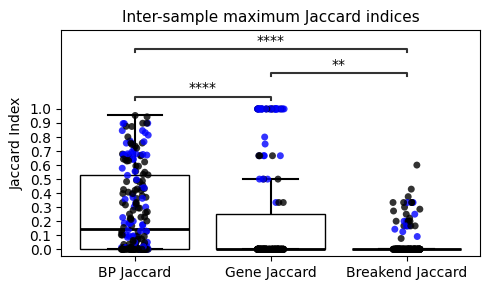

In [33]:
plt.figure(figsize=(5, 3))

ax = sns.boxplot(
    x='Metric',
    y='Jaccard Index',
    data=HC_all_ic_max_jaccs_df_long,
    whis=1.5,
    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(markerfacecolor='white', marker='o', markersize=0)
)

sns.stripplot(
    x='Metric',
    y='strip jaccard',
    data=HC_max_jacc_coloring_df_long,
    hue='color',
    alpha=0.8,
    jitter=True,
    palette=['blue', 'black'] # make first color black for sfig. 12c!
)

pairs = [("BP Jaccard", "Gene Jaccard"), ("BP Jaccard", "Breakend Jaccard"), ("Gene Jaccard", "Breakend Jaccard")]

annotator = Annotator(
    ax,
    pairs,
    data=HC_all_ic_max_jaccs_df_long,
    x='Metric',
    y='Jaccard Index'
)

annotator.configure(
    test="Mann-Whitney",
    comparisons_correction="bonferroni",
    text_format="star",
    loc="inside"
)

annotator.apply_and_annotate()

#plt.ylim(0, 1.2)
plt.yticks([i/10 for i in range(0, 11)])
plt.xlabel("")
plt.ylabel("Jaccard Index")
plt.legend([], [], frameon=False)

plt.title('Inter-sample maximum Jaccard indices', fontsize=11)

plt.tight_layout()
plt.show()

In [34]:
pairs = [
    ("BP Jaccard", "Gene Jaccard"),
    ("BP Jaccard", "Breakend Jaccard"),
    ("Gene Jaccard", "Breakend Jaccard")
]

print("\nPairwise Mann-Whitney Tests")
print("-" * 80)

for g1, g2 in pairs:

    x = HC_all_ic_max_jaccs_df_long.loc[
        HC_all_ic_max_jaccs_df_long["Metric"] == g1,
        "Jaccard Index"
    ].dropna()

    y = HC_all_ic_max_jaccs_df_long.loc[
        HC_all_ic_max_jaccs_df_long["Metric"] == g2,
        "Jaccard Index"
    ].dropna()

    U, p = mannwhitneyu(x, y, alternative="two-sided")

    n1 = len(x)
    n2 = len(y)

    # Rank-biserial correlation
    rbc = (2 * U) / (n1 * n2) - 1

    print(f"{g1} vs {g2}")
    print(f"  n1={n1}, n2={n2}")
    print(f"  U = {U:.1f}")
    print(f"  p = {p:.3e}")
    print(f"  Rank-biserial r = {rbc:.3f}")
    print()


Pairwise Mann-Whitney Tests
--------------------------------------------------------------------------------
BP Jaccard vs Gene Jaccard
  n1=210, n2=210
  U = 29982.0
  p = 1.156e-11
  Rank-biserial r = 0.360

BP Jaccard vs Breakend Jaccard
  n1=210, n2=210
  U = 35947.0
  p = 6.119e-34
  Rank-biserial r = 0.630

Gene Jaccard vs Breakend Jaccard
  n1=210, n2=210
  U = 25000.0
  p = 7.641e-04
  Rank-biserial r = 0.134



### Supp. Fig. 13B

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

BP Jaccard vs. Gene Jaccard: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:6.836e-06 U_stat=2.718e+04
Gene Jaccard vs. Breakend Jaccard: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:1.989e-03 U_stat=2.478e+04
BP Jaccard vs. Breakend Jaccard: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val:8.855e-21 U_stat=3.188e+04


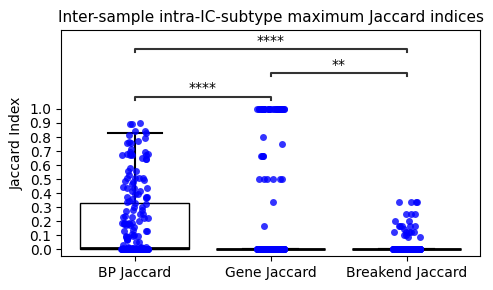

In [29]:
plt.figure(figsize=(5, 3))

ax = sns.boxplot(
    x='Metric',
    y='Jaccard Index',
    data=HC_intra_ic_max_jaccs_df_long,
    whis=1.5,
    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(markerfacecolor='white', marker='o', markersize=0)
)

sns.stripplot(
    x='Metric',
    y='Jaccard Index',
    data=HC_intra_ic_max_jaccs_df_long,
    color='blue',
    alpha=0.8,
    jitter=True
)

# Define comparisons
pairs = [("BP Jaccard", "Gene Jaccard"), ("BP Jaccard", "Breakend Jaccard"), ("Gene Jaccard", "Breakend Jaccard")]

annotator = Annotator(
    ax,
    pairs,
    data=HC_intra_ic_max_jaccs_df_long,
    x='Metric',
    y='Jaccard Index'
)

annotator.configure(
    test="Mann-Whitney",
    comparisons_correction="bonferroni",
    text_format="star",
    loc="inside"
)

annotator.apply_and_annotate()

plt.yticks([i/10 for i in range(0, 11)])
plt.xlabel("")
plt.ylabel("Jaccard Index")

plt.title(
    'Inter-sample intra-IC-subtype maximum Jaccard indices',
    fontsize=11
)

plt.tight_layout()
plt.show()

### Supp. Fig. 13C

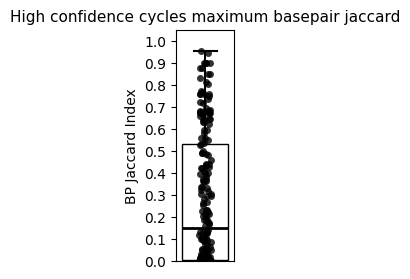

In [39]:
plt.figure(figsize=(0.75, 3))

sns.boxplot(y='BP Jaccard', data=HC_all_ic_max_bp_jaccs_df, whis=1.5,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(markerfacecolor='white', marker='o', markersize=0))

sns.stripplot(y='BP Jaccard', data=HC_all_ic_max_bp_jaccs_df, color='black', alpha=0.8, jitter=True)

plt.ylim(0, 1.05)
plt.yticks([i/10 for i in range(0, 11)])
plt.xticks([])

plt.xlabel("")
plt.ylabel("BP Jaccard Index")

plt.title('High confidence cycles maximum basepair jaccard', fontsize=11)

plt.show()

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_76590/2794529395.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_76590/2794529395.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels, rotation=0, ha='center')


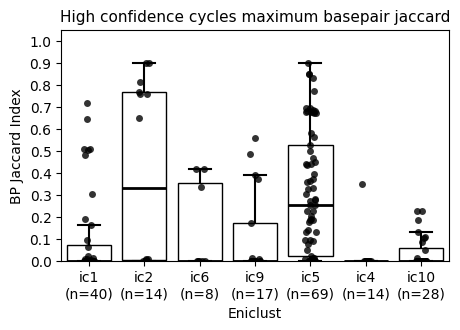

In [45]:
ic_order = ["ic1", "ic2", "ic6", "ic9", "ic5", "ic4", "ic10"]
group_counts = HC_intra_ic_SSE_max_bp_jaccs_df['eniclust'].value_counts().reindex(ic_order).fillna(0).astype(int)

plt.figure(figsize=(5, 3))

sns.boxplot(
    x='eniclust', y='BP Jaccard', data=HC_intra_ic_SSE_max_bp_jaccs_df, palette="Set3", whis=1.5,
    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(markerfacecolor='white', marker='o', markersize=0),
    order=ic_order
)

sns.stripplot(
    x='eniclust', y='BP Jaccard', data=HC_intra_ic_SSE_max_bp_jaccs_df, color='black', alpha=0.8, jitter=True, order=ic_order
)

new_labels = [f"{group}\n(n={count})" for group, count in zip(ic_order, group_counts)]
plt.gca().set_xticklabels(new_labels, rotation=0, ha='center')

plt.ylim(0, 1.05)
plt.yticks([i / 10 for i in range(0, 11)])
plt.xlabel("Eniclust")
plt.ylabel("BP Jaccard Index")
plt.title('High confidence cycles maximum basepair jaccard', fontsize=11)

plt.show()

In [46]:
# Perform Kruskal-Wallis test
kruskal_stat, kruskal_p = kruskal(
    *[HC_intra_ic_SSE_max_bp_jaccs_df[HC_intra_ic_SSE_max_bp_jaccs_df['eniclust'] == group]['BP Jaccard'] for group in ic_order]
)

k = len(ic_order)  # Number of groups
N = len(HC_intra_ic_SSE_max_bp_jaccs_df)  # Total sample size
eta_squared = (kruskal_stat - k + 1) / (N - k)

print(f"p = {kruskal_p}")
print(f"eta squared = {eta_squared}")

p = 3.4172605599606376e-09
eta squared = 0.1839119247520229


In [47]:
# Peform Dunn tests
HC_intra_ic_SSE_max_bp_jaccs_df_NO_NA_IC = HC_intra_ic_SSE_max_bp_jaccs_df.dropna(subset=['BP Jaccard', 'eniclust'])
dunn_results = sp.posthoc_dunn(
    HC_intra_ic_SSE_max_bp_jaccs_df_NO_NA_IC, val_col='BP Jaccard', group_col='eniclust', p_adjust='bonferroni'
)
print(dunn_results)

              ic1      ic10       ic2   ic3/ic7       ic4       ic5       ic6  \
ic1      1.000000  1.000000  0.193057  1.000000  1.000000  0.000154  1.000000   
ic10     1.000000  1.000000  0.050096  1.000000  1.000000  0.000037  1.000000   
ic2      0.193057  0.050096  1.000000  1.000000  0.008597  1.000000  1.000000   
ic3/ic7  1.000000  1.000000  1.000000  1.000000  1.000000  0.309049  1.000000   
ic4      1.000000  1.000000  0.008597  1.000000  1.000000  0.000034  1.000000   
ic5      0.000154  0.000037  1.000000  0.309049  0.000034  1.000000  0.994449   
ic6      1.000000  1.000000  1.000000  1.000000  1.000000  0.994449  1.000000   
ic8      1.000000  1.000000  1.000000  1.000000  1.000000  1.000000  1.000000   
ic9      1.000000  1.000000  0.853740  1.000000  1.000000  0.050199  1.000000   

         ic8       ic9  
ic1      1.0  1.000000  
ic10     1.0  1.000000  
ic2      1.0  0.853740  
ic3/ic7  1.0  1.000000  
ic4      1.0  1.000000  
ic5      1.0  0.050199  
ic6      1.0  

### Supp. Fig. 13D

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_76590/3350023262.py:28: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


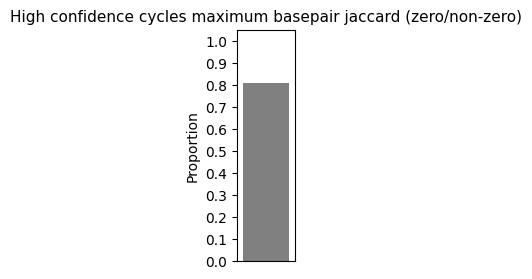

In [50]:
counts = pd.Series({
    'Zero': (HC_all_ic_max_bp_jaccs_df['BP Jaccard'] == 0).sum(),
    'Non-zero': (HC_all_ic_max_bp_jaccs_df['BP Jaccard'] != 0).sum()
})

proportions = counts / counts.sum()

fig, ax = plt.subplots(figsize=(0.75, 3))

ax.bar(
    x=0, width=0.6, 
    bottom=0, color='grey', label='Non-zero', height=proportions['Non-zero']
)
ax.bar(
    x=0, width=0.7, 
    bottom=proportions['Non-zero'], color='white', label='Non-zero', height=proportions['Zero']
)

plt.xlabel("Eniclust")
plt.ylabel("Proportion")
plt.title("High confidence cycles maximum basepair jaccard (zero/non-zero)", fontsize=11)
plt.yticks([i / 10 for i in range(0, 11)])

ax.set_xticks([])
ax.set_xlabel("")

# Show the plot
plt.tight_layout()
plt.show()

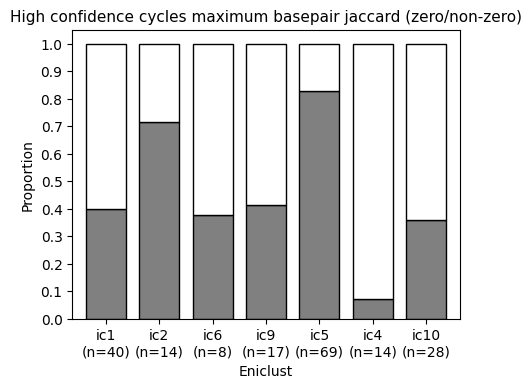

In [51]:
ic_order = ["ic1", "ic2", "ic6", "ic9", "ic5", "ic4", "ic10"]
group_counts = HC_intra_ic_SSE_max_bp_jaccs_df['eniclust'].value_counts().reindex(ic_order).fillna(0).astype(int)
proportions = HC_intra_ic_SSE_max_bp_jaccs_df.groupby('eniclust')['BP Jaccard'] \
    .apply(lambda x: pd.Series({'Zero': (x == 0).sum(), 'Non-zero': (x != 0).sum()})) \
    .unstack()

proportions_normalized = proportions.div(proportions.sum(axis=1), axis=0)
proportions_normalized = proportions_normalized[['Non-zero', 'Zero']]
proportions_normalized = proportions_normalized.loc[ic_order]

ax = proportions_normalized.plot(
    kind='bar', stacked=True, figsize=(5, 3.75), 
    color=['grey', 'white'],  
    edgecolor='black', width=0.75
)

plt.xlabel("Eniclust")
plt.ylabel("Proportion")
plt.title("High confidence cycles maximum basepair jaccard (zero/non-zero)", fontsize=11)
plt.xticks(rotation=0)
plt.yticks([i / 10 for i in range(0, 11)])

new_labels = [f"{group}\n(n={count})" for group, count in zip(ic_order, group_counts)]
ax.set_xticklabels(new_labels)
ax.get_legend().remove()

plt.show()

In [54]:
# Perform Chi-squared test
contingency_table = proportions.values
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

# effect size calculation (Cramer's V)
n = contingency_table.sum().sum()
k = contingency_table.shape[1]
r = contingency_table.shape[0]

cramers_v = np.sqrt(chi2_stat / (n * min(k - 1, r - 1)))

print(f"p = {p_val}")
print(f"Cramer's V = {cramers_v}")

p = 2.0755843850181364e-07
Cramer's V = 0.46959774438362617


### Supp. Fig. 13E

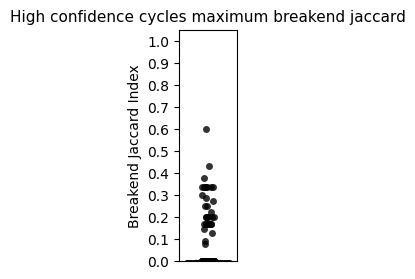

In [56]:
plt.figure(figsize=(0.75, 3))

sns.boxplot(y='Breakend Jaccard', data=HC_all_ic_max_be_jaccs_df, whis=1.5,
            boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
            whiskerprops=dict(color='black', linewidth=1.5),
            capprops=dict(color='black', linewidth=1.5),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(markerfacecolor='white', marker='o', markersize=0))

sns.stripplot(y='Breakend Jaccard', data=HC_all_ic_max_be_jaccs_df, color='black', alpha=0.8, jitter=True)

plt.ylim(0, 1.05)
plt.yticks([i/10 for i in range(0, 11)])
plt.xticks([])

plt.xlabel("")
plt.ylabel("Breakend Jaccard Index")

plt.title('High confidence cycles maximum breakend jaccard', fontsize=11)

plt.show()

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_76590/3687819511.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_76590/3687819511.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_xticklabels(new_labels, rotation=0, ha='center')


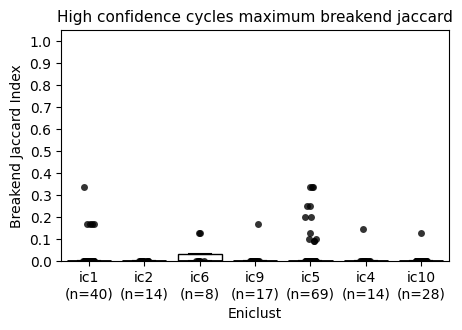

In [57]:
ic_order = ["ic1", "ic2", "ic6", "ic9", "ic5", "ic4", "ic10"]
group_counts = HC_intra_ic_SSE_max_be_jaccs_df['eniclust'].value_counts().reindex(ic_order).fillna(0).astype(int)

plt.figure(figsize=(5, 3))

sns.boxplot(
    x='eniclust', y='Breakend Jaccard', data=HC_intra_ic_SSE_max_be_jaccs_df, palette="Set3", whis=1.5,
    boxprops=dict(facecolor='white', edgecolor='black', linewidth=1),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(markerfacecolor='white', marker='o', markersize=0),
    order=ic_order
)

sns.stripplot(
    x='eniclust', y='Breakend Jaccard', data=HC_intra_ic_SSE_max_be_jaccs_df, color='black', alpha=0.8, jitter=True, order=ic_order
)

new_labels = [f"{group}\n(n={count})" for group, count in zip(ic_order, group_counts)]
plt.gca().set_xticklabels(new_labels, rotation=0, ha='center')

plt.ylim(0, 1.05)
plt.yticks([i / 10 for i in range(0, 11)])
plt.xlabel("Eniclust")
plt.ylabel("Breakend Jaccard Index")
plt.title('High confidence cycles maximum breakend jaccard', fontsize=11)

plt.show()

In [58]:
# Perform Kruskal-Wallis test
kruskal_stat, kruskal_p = kruskal(
    *[HC_intra_ic_SSE_max_be_jaccs_df[HC_intra_ic_SSE_max_be_jaccs_df['eniclust'] == group]['Breakend Jaccard'] for group in ic_order]
)

k = len(ic_order)  # Number of groups
N = len(HC_intra_ic_SSE_max_be_jaccs_df)  # Total sample size
eta_squared = (kruskal_stat - k + 1) / (N - k)

print(f"p = {kruskal_p}")
print(f"eta squared = {eta_squared}")

p = 0.24064654081513567
eta squared = 0.00808821220802427


### Supp. Fig. 13F

/var/folders/tj/d3m703xd2jzgm22qd2c_2_640000gq/T/ipykernel_76590/1865670113.py:28: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


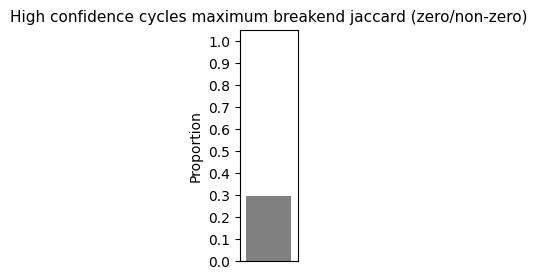

In [60]:
counts = pd.Series({
    'Zero': (HC_all_ic_max_be_jaccs_df['Breakend Jaccard'] == 0).sum(),
    'Non-zero': (HC_all_ic_max_be_jaccs_df['Breakend Jaccard'] != 0).sum()
})

proportions = counts / counts.sum()

fig, ax = plt.subplots(figsize=(0.75, 3))

ax.bar(
    x=0, width=0.6, 
    bottom=0, color='grey', label='Non-zero', height=proportions['Non-zero']
)
ax.bar(
    x=0, width=0.7, 
    bottom=proportions['Non-zero'], color='white', label='Non-zero', height=proportions['Zero']
)

plt.xlabel("Eniclust")
plt.ylabel("Proportion")
plt.title("High confidence cycles maximum breakend jaccard (zero/non-zero)", fontsize=11)
plt.yticks([i / 10 for i in range(0, 11)])

ax.set_xticks([])
ax.set_xlabel("")

# Show the plot
plt.tight_layout()
plt.show()

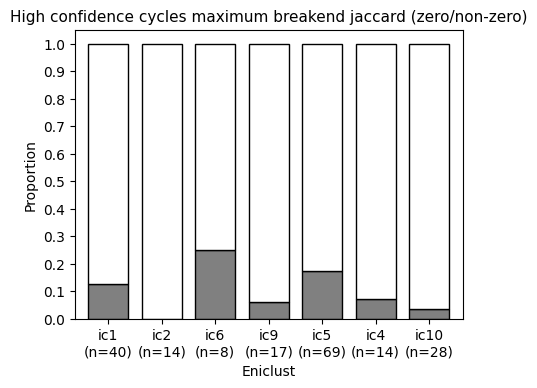

In [61]:
ic_order = ["ic1", "ic2", "ic6", "ic9", "ic5", "ic4", "ic10"]
group_counts = HC_intra_ic_SSE_max_be_jaccs_df['eniclust'].value_counts().reindex(ic_order).fillna(0).astype(int)
proportions = HC_intra_ic_SSE_max_be_jaccs_df.groupby('eniclust')['Breakend Jaccard'] \
    .apply(lambda x: pd.Series({'Zero': (x == 0).sum(), 'Non-zero': (x != 0).sum()})) \
    .unstack()

proportions_normalized = proportions.div(proportions.sum(axis=1), axis=0)
proportions_normalized = proportions_normalized[['Non-zero', 'Zero']]
proportions_normalized = proportions_normalized.loc[ic_order]

ax = proportions_normalized.plot(
    kind='bar', stacked=True, figsize=(5, 3.75), 
    color=['grey', 'white'],  
    edgecolor='black', width=0.75
)

plt.xlabel("Eniclust")
plt.ylabel("Proportion")
plt.title("High confidence cycles maximum breakend jaccard (zero/non-zero)", fontsize=11)
plt.xticks(rotation=0)
plt.yticks([i / 10 for i in range(0, 11)])

new_labels = [f"{group}\n(n={count})" for group, count in zip(ic_order, group_counts)]
ax.set_xticklabels(new_labels)
ax.get_legend().remove()

plt.show()

In [63]:
# Perform Chi-squared test
contingency_table = proportions.values
chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)

# effect size calculation (Cramer's V)
n = contingency_table.sum().sum()
k = contingency_table.shape[1]
r = contingency_table.shape[0]

cramers_v = np.sqrt(chi2_stat / (n * min(k - 1, r - 1)))

print(f"p = {p_val}")
print(f"Cramer's V = {cramers_v}")

p = 0.37730557525048053
Cramer's V = 0.20234710113716337
